In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

Best options for classification target: \
Inventory_Status (Days_of_Inventory, Avg_Daily_Sales, Reorder_Point, Safety_Stock, Lead_Time_Days)\
ABC_Class (Total_Inventory_Value_USD, Avg_Daily_Sales, Order_Frequency_per_month)\
convert a numeric variable to categorical (SKU_Churn_Rate or Demand_Forecast_Accuracy_PCT)

Data Cleaning

In [34]:
data = pd.read_csv("Inventory Management E-Grocery - InventoryData.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   SKU_ID                        1000 non-null   object 
 1   SKU_Name                      1000 non-null   object 
 2   Category                      1000 non-null   object 
 3   ABC_Class                     1000 non-null   object 
 4   Supplier_ID                   1000 non-null   object 
 5   Supplier_Name                 1000 non-null   object 
 6   Warehouse_ID                  1000 non-null   object 
 7   Warehouse_Location            1000 non-null   object 
 8   Batch_ID                      1000 non-null   object 
 9   Received_Date                 1000 non-null   object 
 10  Last_Purchase_Date            1000 non-null   object 
 11  Expiry_Date                   1000 non-null   object 
 12  Stock_Age_Days                1000 non-null   int64  
 13  Quan

In [35]:
data.iloc[:,1:20]

,SKU_Name,Category,ABC_Class,Supplier_ID,Supplier_Name,Warehouse_ID,Warehouse_Location,Batch_ID,Received_Date,Last_Purchase_Date,Expiry_Date,Stock_Age_Days,Quantity_On_Hand,Quantity_Reserved,Quantity_Committed,Damaged_Qty,Returns_Qty,Avg_Daily_Sales,Forecast_Next_30d
0,Pantry Product 13,Pantry,A,S005,PT Agro Raya,WHBDG,Bandung - Rancaekek,BATCH2679,2025-07-14,2025-06-01,2027-04-25,57,359,100,36,0,0,"28,57",971.000
1,Fresh Product 112,Fresh Produce,C,S004,PT Nusantara Supplier,WHDPS,Denpasar - Tabanan,BATCH4257,2025-04-08,2025-02-22,2025-04-11,154,314,64,0,0,1,"34,99",796.000
2,Meat Product 446,Meat,B,S001,PT Segar Makmur,WHBDG,Bandung - Rancaekek,BATCH6574,2025-03-15,2025-02-26,2025-04-02,178,485,28,62,3,1,"36,55",1.377
3,Seafood Product 48,Seafood,A,S007,PT Bakerindo,WHJKT,Jakarta - Cengkareng,BATCH5333,2025-06-10,2025-04-20,2025-06-18,91,281,92,49,0,0,"25,49",716.000
4,Personal Product 194,Personal Care,A,S002,PT Indo Fresh,WHDPS,Denpasar - Tabanan,BATCH6925,2025-06-26,2025-05-21,2030-01-03,75,235,63,33,0,2,"17,05",518.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Fresh Product 377,Fresh Produce,C,S006,PT Frozen Express,WHJKT,Jakarta - Cengkareng,BATCH8871,2025-07-20,2025-06-02,2025-07-25,51,382,64,48,1,0,"31,90",678.000
996,Frozen Product 125,Frozen,C,S001,PT Segar Makmur,WHDPS,Denpasar - Tabanan,BATCH9906,2025-03-16,2025-03-09,2025-11-19,177,208,27,96,0,1,"40,03",1.019
997,Fresh Product 454,Fresh Produce,C,S007,PT Bakerindo,WHBDG,Bandung - Rancaekek,BATCH1393,2025-09-09,2025-08-26,2025-09-15,0,264,48,13,1,2,"26,13",797.000
998,Meat Product 451,Meat,C,S007,PT Bakerindo,WHJKT,Jakarta - Cengkareng,BATCH2804,2025-05-07,2025-04-23,2025-05-17,125,33,33,0,2,2,"23,48",676.000


In [36]:
data.iloc[:,20:37]

,Days_of_Inventory,Reorder_Point,Safety_Stock,Lead_Time_Days,Unit_Cost_USD,Last_Purchase_Price_USD,Total_Inventory_Value_USD,SKU_Churn_Rate,Order_Frequency_per_month,Supplier_OnTime_Pct,FIFO_FEFO,Inventory_Status,Count_Variance,Audit_Date,Audit_Variance_Pct,Demand_Forecast_Accuracy_Pct,Notes
0,"12,57",51.0,22,1,"$5,81","$5,71","$2.084,25","2,39","5,00","70,68%",FIFO,In Stock,0,2025-06-26,"-7,14%","95,67%",NaN
1,"8,97",744.0,254,14,"$1,45","$1,33","$456,71","3,34","12,00","84,61%",FEFO,Low Stock,4,2025-08-12,"2,15%","86,00%",NaN
2,"13,27",225.0,79,4,"$1,86","$1,69","$902,63","2,26","11,00","85,36%",FIFO,Expiring Soon,-5,2025-08-13,"6,85%","87,64%",NaN
3,"11,02",162.0,60,4,"$14,50","$14,12","$4.073,15","2,72","10,00","72,81%",FIFO,Expiring Soon,0,2025-07-13,"-6,69%","71,15%",NaN
4,"13,78",80.0,29,3,"$9,46","$10,31","$2.222,91","2,18","2,00","70,93%",FIFO,In Stock,-5,2025-06-11,"1,23%","76,25%",High return rate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,"11,97",485.0,166,10,"$0,99","$1,05","$379,21","2,51","8,00","79,06%",FEFO,Low Stock,2,2025-08-20,"-6,23%","80,85%",NaN
996,"5,20",307.0,107,5,"$2,54","$2,31","$527,28","5,77","15,00","74,40%",FIFO,Low Stock,0,2025-09-04,"1,33%","88,43%",Promotional item
997,"10,10",394.0,133,10,"$0,69","$0,71","$181,39","2,97","9,00","92,17%",FEFO,Low Stock,0,2025-07-22,"5,47%","91,92%",Promotional item
998,"1,41",181.0,64,5,"$2,38","$2,71","$78,48","21,35","13,00","92,40%",FIFO,Low Stock,0,2025-08-04,"0,46%","93,18%",NaN


In [37]:
def clean_symbols(col):
    col = col.astype(str)

    # Remove currency + percent symbols FIRST
    col = col.str.replace(r'[\$]', '', regex=True)  # removes $ and commas

    # Remove % separately (so we can optionally divide later)
    col = col.str.replace('%', '', regex=False)

    return col

def clean_numeric_column(col, is_percent=False):
    col = col.astype(str)
    
    # Handle European format: 1.234,56 → 1234.56
    col = col.str.replace(r'\.(?=\d{3}(?:,|$))', '', regex=True)
    col = col.str.replace(',', '.', regex=False)

    # Convert to numeric
    col = pd.to_numeric(col, errors='coerce')

    # Convert percentages if needed
    if is_percent:
        col = col / 100

    return col

In [38]:
data['Last_Purchase_Price_USD'] = clean_symbols(data['Last_Purchase_Price_USD'])
data['Total_Inventory_Value_USD'] = clean_symbols(data['Total_Inventory_Value_USD'])
data['Unit_Cost_USD'] = clean_symbols(data['Unit_Cost_USD'])
data['Supplier_OnTime_Pct'] = clean_symbols(data['Supplier_OnTime_Pct'])
data['Audit_Variance_Pct'] = clean_symbols(data['Audit_Variance_Pct'])
data['Demand_Forecast_Accuracy_Pct'] = clean_symbols(data['Demand_Forecast_Accuracy_Pct'])

In [39]:
data['Avg_Daily_Sales'] = clean_numeric_column(data['Avg_Daily_Sales'])
data['Days_of_Inventory'] = clean_numeric_column(data['Days_of_Inventory'])
data['Unit_Cost_USD'] = clean_numeric_column(data['Unit_Cost_USD'])
data['Last_Purchase_Price_USD'] = clean_numeric_column(data['Last_Purchase_Price_USD'])
data['Total_Inventory_Value_USD'] = clean_numeric_column(data['Total_Inventory_Value_USD'])
data['SKU_Churn_Rate'] = clean_numeric_column(data['SKU_Churn_Rate'])
data['Order_Frequency_per_month'] = clean_numeric_column(data['Order_Frequency_per_month'])
data['Supplier_OnTime_Pct'] = clean_numeric_column(data['Supplier_OnTime_Pct'], is_percent=True)
data['Audit_Variance_Pct'] = clean_numeric_column(data['Audit_Variance_Pct'], is_percent=True)
data['Demand_Forecast_Accuracy_Pct'] = clean_numeric_column(data['Demand_Forecast_Accuracy_Pct'], is_percent=True)

In [40]:
data['Forecast_Next_30d'] = (data['Forecast_Next_30d'] * 1000).astype(int)

In [41]:
data.iloc[:,1:20]

,SKU_Name,Category,ABC_Class,Supplier_ID,Supplier_Name,Warehouse_ID,Warehouse_Location,Batch_ID,Received_Date,Last_Purchase_Date,Expiry_Date,Stock_Age_Days,Quantity_On_Hand,Quantity_Reserved,Quantity_Committed,Damaged_Qty,Returns_Qty,Avg_Daily_Sales,Forecast_Next_30d
0,Pantry Product 13,Pantry,A,S005,PT Agro Raya,WHBDG,Bandung - Rancaekek,BATCH2679,2025-07-14,2025-06-01,2027-04-25,57,359,100,36,0,0,28.57,971000
1,Fresh Product 112,Fresh Produce,C,S004,PT Nusantara Supplier,WHDPS,Denpasar - Tabanan,BATCH4257,2025-04-08,2025-02-22,2025-04-11,154,314,64,0,0,1,34.99,796000
2,Meat Product 446,Meat,B,S001,PT Segar Makmur,WHBDG,Bandung - Rancaekek,BATCH6574,2025-03-15,2025-02-26,2025-04-02,178,485,28,62,3,1,36.55,1377
3,Seafood Product 48,Seafood,A,S007,PT Bakerindo,WHJKT,Jakarta - Cengkareng,BATCH5333,2025-06-10,2025-04-20,2025-06-18,91,281,92,49,0,0,25.49,716000
4,Personal Product 194,Personal Care,A,S002,PT Indo Fresh,WHDPS,Denpasar - Tabanan,BATCH6925,2025-06-26,2025-05-21,2030-01-03,75,235,63,33,0,2,17.05,518000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Fresh Product 377,Fresh Produce,C,S006,PT Frozen Express,WHJKT,Jakarta - Cengkareng,BATCH8871,2025-07-20,2025-06-02,2025-07-25,51,382,64,48,1,0,31.90,678000
996,Frozen Product 125,Frozen,C,S001,PT Segar Makmur,WHDPS,Denpasar - Tabanan,BATCH9906,2025-03-16,2025-03-09,2025-11-19,177,208,27,96,0,1,40.03,1018
997,Fresh Product 454,Fresh Produce,C,S007,PT Bakerindo,WHBDG,Bandung - Rancaekek,BATCH1393,2025-09-09,2025-08-26,2025-09-15,0,264,48,13,1,2,26.13,797000
998,Meat Product 451,Meat,C,S007,PT Bakerindo,WHJKT,Jakarta - Cengkareng,BATCH2804,2025-05-07,2025-04-23,2025-05-17,125,33,33,0,2,2,23.48,676000


In [42]:
data.iloc[:,20:37]

,Days_of_Inventory,Reorder_Point,Safety_Stock,Lead_Time_Days,Unit_Cost_USD,Last_Purchase_Price_USD,Total_Inventory_Value_USD,SKU_Churn_Rate,Order_Frequency_per_month,Supplier_OnTime_Pct,FIFO_FEFO,Inventory_Status,Count_Variance,Audit_Date,Audit_Variance_Pct,Demand_Forecast_Accuracy_Pct,Notes
0,12.57,51.0,22,1,5.81,5.71,2084.25,2.39,5.0,0.7068,FIFO,In Stock,0,2025-06-26,-0.0714,0.9567,NaN
1,8.97,744.0,254,14,1.45,1.33,456.71,3.34,12.0,0.8461,FEFO,Low Stock,4,2025-08-12,0.0215,0.8600,NaN
2,13.27,225.0,79,4,1.86,1.69,902.63,2.26,11.0,0.8536,FIFO,Expiring Soon,-5,2025-08-13,0.0685,0.8764,NaN
3,11.02,162.0,60,4,14.50,14.12,4073.15,2.72,10.0,0.7281,FIFO,Expiring Soon,0,2025-07-13,-0.0669,0.7115,NaN
4,13.78,80.0,29,3,9.46,10.31,2222.91,2.18,2.0,0.7093,FIFO,In Stock,-5,2025-06-11,0.0123,0.7625,High return rate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,11.97,485.0,166,10,0.99,1.05,379.21,2.51,8.0,0.7906,FEFO,Low Stock,2,2025-08-20,-0.0623,0.8085,NaN
996,5.20,307.0,107,5,2.54,2.31,527.28,5.77,15.0,0.7440,FIFO,Low Stock,0,2025-09-04,0.0133,0.8843,Promotional item
997,10.10,394.0,133,10,0.69,0.71,181.39,2.97,9.0,0.9217,FEFO,Low Stock,0,2025-07-22,0.0547,0.9192,Promotional item
998,1.41,181.0,64,5,2.38,2.71,78.48,21.35,13.0,0.9240,FIFO,Low Stock,0,2025-08-04,0.0046,0.9318,NaN


EDA

In [43]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   SKU_ID                        1000 non-null   object 
 1   SKU_Name                      1000 non-null   object 
 2   Category                      1000 non-null   object 
 3   ABC_Class                     1000 non-null   object 
 4   Supplier_ID                   1000 non-null   object 
 5   Supplier_Name                 1000 non-null   object 
 6   Warehouse_ID                  1000 non-null   object 
 7   Warehouse_Location            1000 non-null   object 
 8   Batch_ID                      1000 non-null   object 
 9   Received_Date                 1000 non-null   object 
 10  Last_Purchase_Date            1000 non-null   object 
 11  Expiry_Date                   1000 non-null   object 
 12  Stock_Age_Days                1000 non-null   int64  
 13  Quan

Exploratory Data Analysis

In [44]:
data['Inventory_Status'].unique()

array(['In Stock', 'Low Stock', 'Expiring Soon', 'Out of Stock'],
      dtype=object)

In [45]:
data['ABC_Class'].unique()

array(['A', 'C', 'B'], dtype=object)

In [46]:
data.columns[data.isnull().any()].tolist()

['Notes']

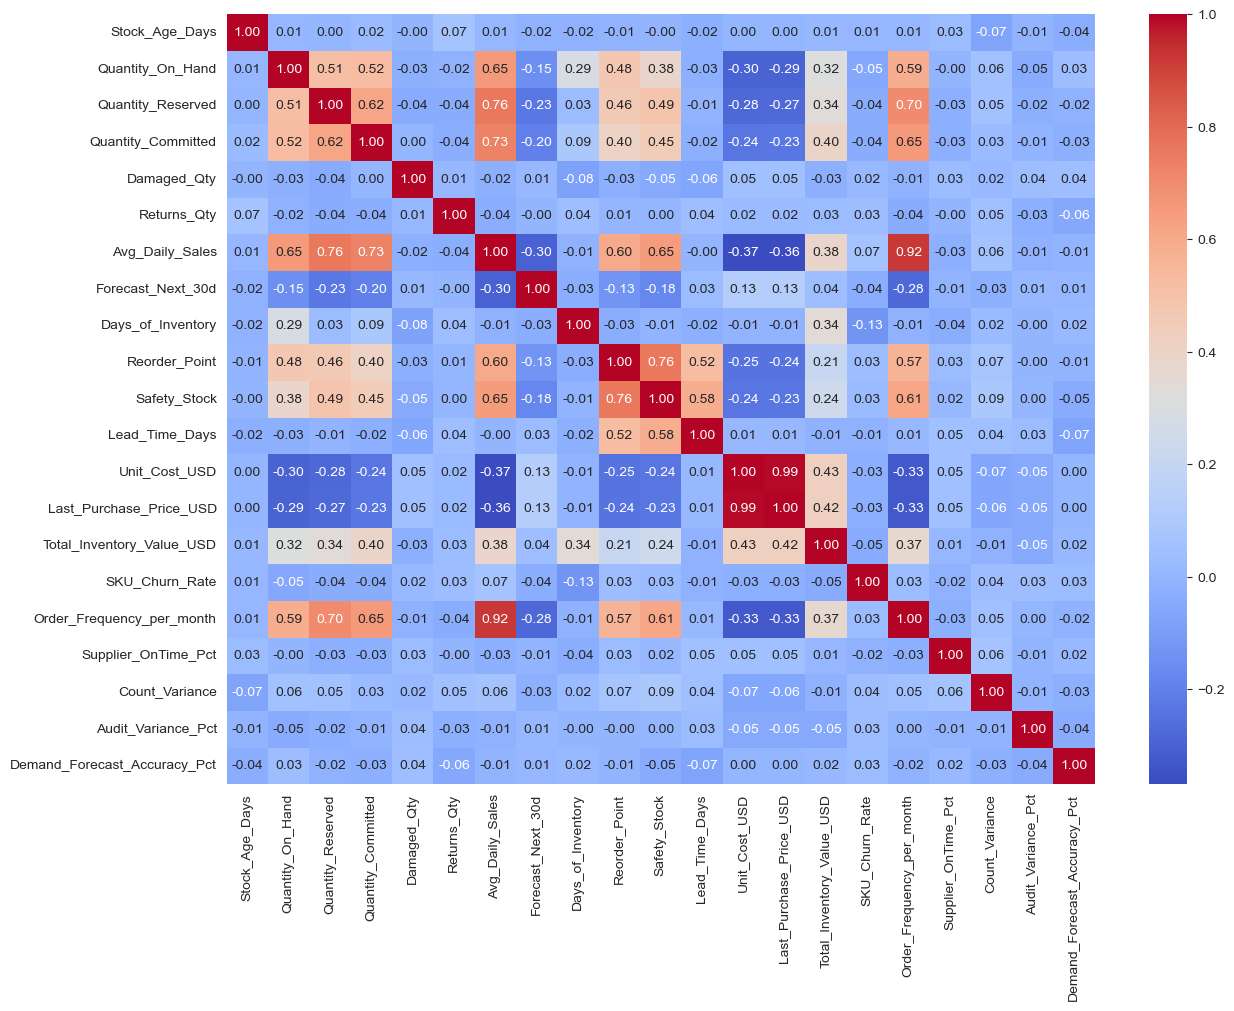

In [47]:
corr = data.corr(numeric_only=True)

# Correlation plot
plt.figure(figsize=(14, 10)) 
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

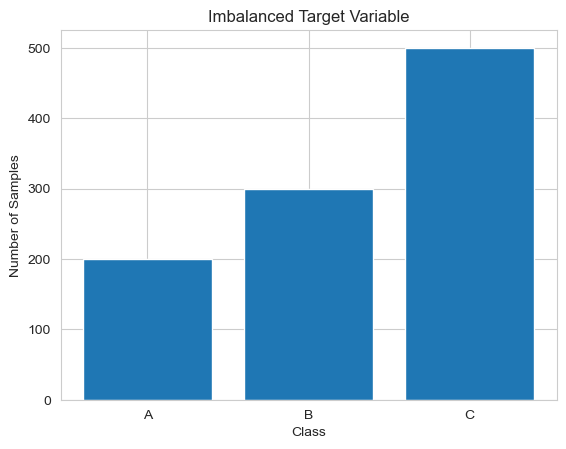

In [48]:
# Counting how many observations fall in each class
class_counts = data['ABC_Class'].value_counts().sort_index()

# Plotting the count of class to show imbalance
plt.figure()
plt.bar(["A", "B", "C"], class_counts.values)
plt.title("Imbalanced Target Variable")
plt.ylabel("Number of Samples")
plt.xlabel("Class")

plt.show()

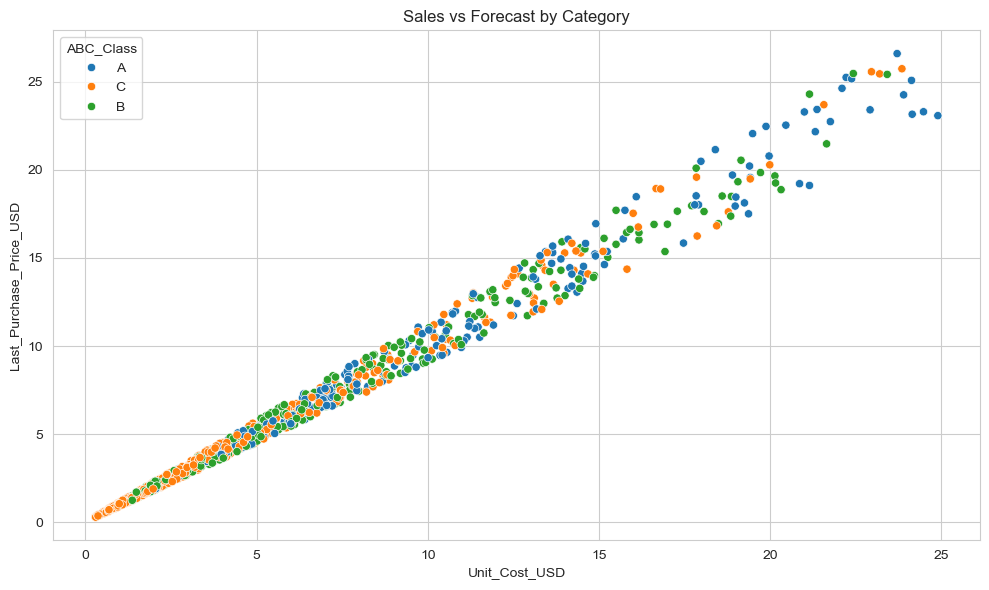

In [49]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x='Unit_Cost_USD',
    y='Last_Purchase_Price_USD',
    hue='ABC_Class'  
)

plt.title("Sales vs Forecast by Category")
plt.tight_layout()
plt.show()

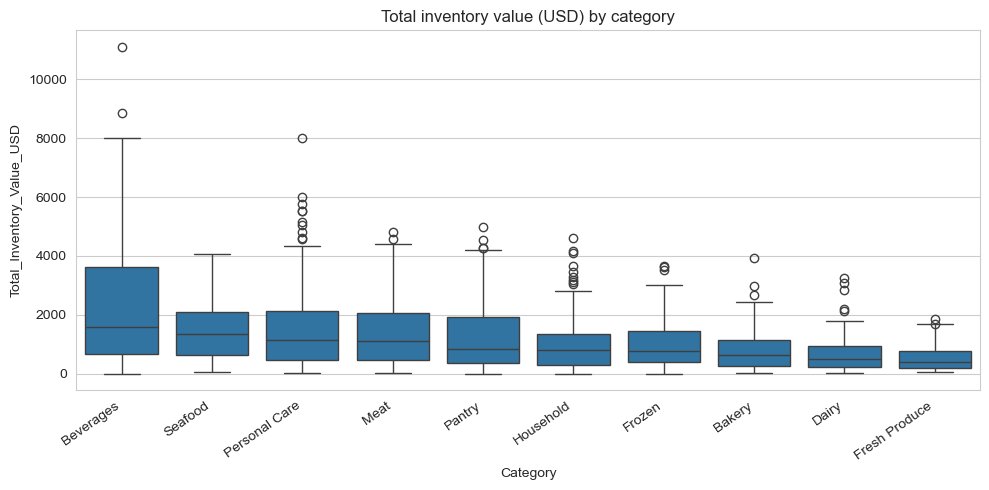

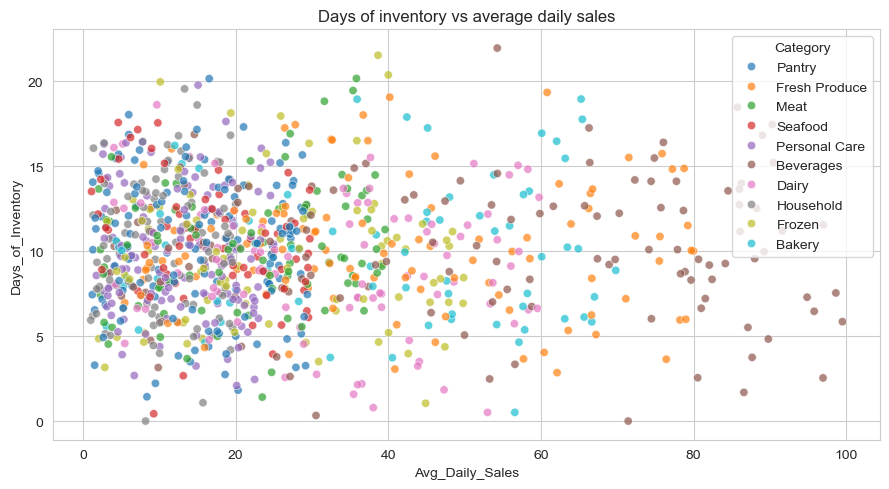

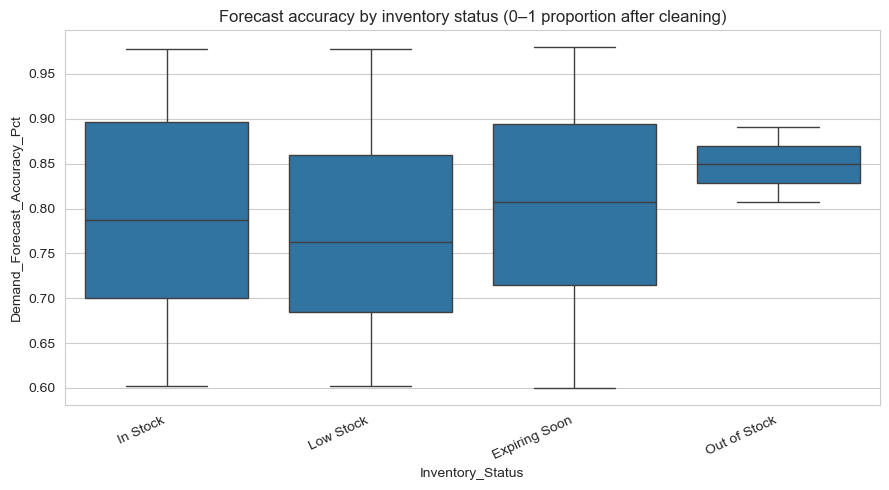

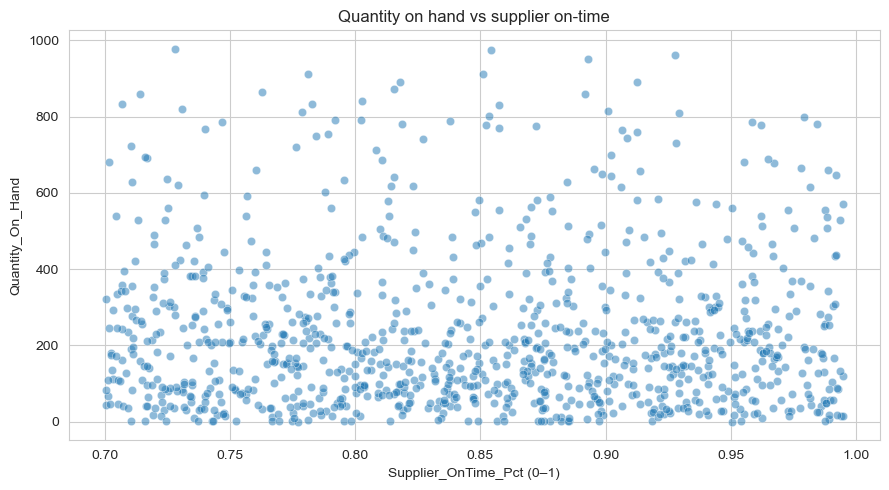

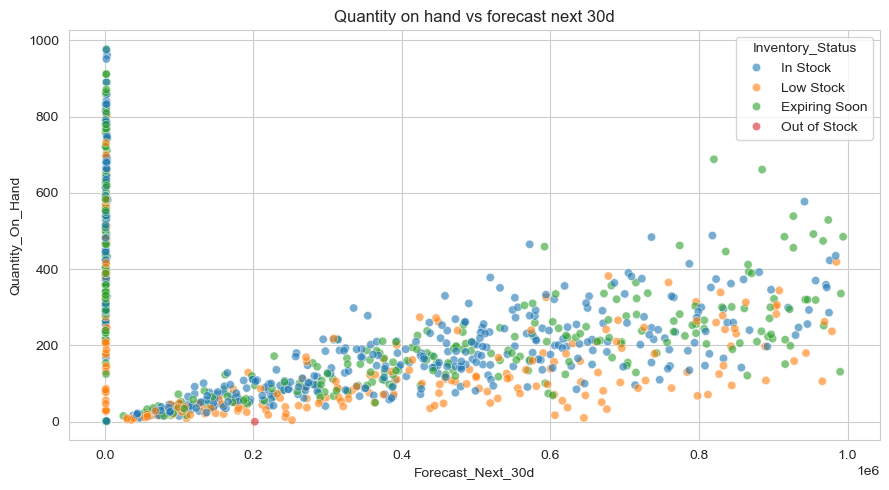

In [50]:
sns.set_style("whitegrid")

if "Category" in data.columns and "Total_Inventory_Value_USD" in data.columns:
    plt.figure(figsize=(10, 5))
    order = data.groupby("Category")["Total_Inventory_Value_USD"].median().sort_values(ascending=False).index
    sns.boxplot(data=data, x="Category", y="Total_Inventory_Value_USD", order=order)
    plt.xticks(rotation=35, ha="right")
    plt.title("Total inventory value (USD) by category")
    plt.tight_layout()
    plt.show()

if "Days_of_Inventory" in data.columns and "Avg_Daily_Sales" in data.columns:
    plt.figure(figsize=(9, 5))
    sns.scatterplot(
        data=data,
        x="Avg_Daily_Sales",
        y="Days_of_Inventory",
        hue="Category" if "Category" in data.columns else None,
        alpha=0.7,
    )
    plt.title("Days of inventory vs average daily sales")
    plt.tight_layout()
    plt.show()

if "Inventory_Status" in data.columns and "Demand_Forecast_Accuracy_Pct" in data.columns:
    plt.figure(figsize=(9, 5))
    sns.boxplot(data=data, x="Inventory_Status", y="Demand_Forecast_Accuracy_Pct")
    plt.xticks(rotation=25, ha="right")
    plt.title("Forecast accuracy by inventory status (0–1 proportion after cleaning)")
    plt.ylabel("Demand_Forecast_Accuracy_Pct")
    plt.tight_layout()
    plt.show()

if "Supplier_OnTime_Pct" in data.columns and "Quantity_On_Hand" in data.columns:
    plt.figure(figsize=(9, 5))
    sns.scatterplot(data=data, x="Supplier_OnTime_Pct", y="Quantity_On_Hand", alpha=0.5)
    plt.xlabel("Supplier_OnTime_Pct (0–1)")
    plt.title("Quantity on hand vs supplier on-time")
    plt.tight_layout()
    plt.show()

if "Quantity_On_Hand" in data.columns and "Forecast_Next_30d" in data.columns:
    plt.figure(figsize=(9, 5))
    sns.scatterplot(
        data=data,
        x="Forecast_Next_30d",
        y="Quantity_On_Hand",
        hue="Inventory_Status" if "Inventory_Status" in data.columns else None,
        alpha=0.6,
    )
    plt.title("Quantity on hand vs forecast next 30d")
    plt.tight_layout()
    plt.show()


Training a Naive Bayes model as a baseline model

In [71]:
X = data.drop(columns=["ABC_Class", "Total_Inventory_Value_USD"])
y = data["ABC_Class"]

In [72]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns

In [73]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
    ]
)

In [74]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GaussianNB())
])

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=16
)

In [76]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [77]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.42

Confusion Matrix:
 [[18 26  0]
 [16 45  1]
 [ 7 66 21]]

Classification Report:
               precision    recall  f1-score   support

           A       0.44      0.41      0.42        44
           B       0.33      0.73      0.45        62
           C       0.95      0.22      0.36        94

    accuracy                           0.42       200
   macro avg       0.57      0.45      0.41       200
weighted avg       0.65      0.42      0.40       200



Novel Model

Lasso Regression

In [78]:
lasso_model = LogisticRegression(
    penalty="l1",
    solver="saga",   # required for L1
    max_iter=5000,
    class_weight="balanced"
)

In [79]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", lasso_model)
])

In [80]:
param_grid = {
    "model__C": np.logspace(-3, 2, 10)  # from 0.001 to 100
}

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=16, stratify=y
)

In [82]:
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['Stock_Age_Days', 'Quantity_On_Hand', 'Quantity_Reserved',
       'Quantity_Committed', 'Damaged_Qty', 'Returns_Qty', 'Avg_Daily_Sales',
       'Forecast_Next_30d', 'Days_of_Inventory', 'Reorder_Point',
       'Safety_Stock', 'Lead_Time_Days', 'Unit_Cost_USD',...
       'Audit_Variance_Pct', 'Demand_Forecast_Accuracy_Pct'],
      dtype='object'))])),
                                       ('model',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=5000,
                                                           penalty='l1',
                                                           solver='saga'))]),
             n_jobs=-1,
             param_grid={'model__C': array([1.00000000e-03, 3.59381366e-03, 1.29154967e-02, 4.64158883e-02,
       1.66810054e-01, 5.99484250e-01, 2.15443469e+00, 7.74263683e+00,
       2.78255940e+01, 1.00000000e+02])},
             scoring='accuracy')

In [83]:
print("Best C:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best C: {'model__C': np.float64(27.825594022071257)}
Best CV Score: 0.7675000000000001


In [84]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

matrix = confusion_matrix(y_test, y_pred)
print(matrix)

Test Accuracy: 0.735
Train Accuracy: 0.76875

Classification Report:
               precision    recall  f1-score   support

           A       0.63      0.85      0.72        40
           B       0.63      0.55      0.59        60
           C       0.85      0.80      0.82       100

    accuracy                           0.73       200
   macro avg       0.71      0.73      0.71       200
weighted avg       0.74      0.73      0.73       200

[[34  6  0]
 [13 33 14]
 [ 7 13 80]]


In [85]:
# Get feature names after preprocessing
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

# Get coefficients
coefficients = best_model.named_steps["model"].coef_[0]

# Combine into DataFrame
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": np.exp(coefficients)
})

# Show most important features
coef_df = coef_df.sort_values(by="Coefficient", key=abs, ascending=False)
coef_df['Feature'] = coef_df['Feature'].apply(lambda x: x.lstrip("num_"))
print(coef_df.head(20))

                         Feature  Coefficient
12                 Unit_Cost_USD    85.904149
6                Avg_Daily_Sales     5.464449
8              Days_of_Inventory     3.631996
7              Forecast_Next_30d     2.542576
1               Quantity_On_Hand     1.918111
15     Order_Frequency_per_month     1.583943
10                  Safety_Stock     1.304770
5                    Returns_Qty     1.201129
2              Quantity_Reserved     1.095384
16           Supplier_OnTime_Pct     1.085229
19  Demand_Forecast_Accuracy_Pct     1.074965
0                 Stock_Age_Days     1.058286
9                  Reorder_Point     1.038995
3             Quantity_Committed     1.000000
4                    Damaged_Qty     0.939156
17                Count_Variance     0.876262
18            Audit_Variance_Pct     0.823385
11                Lead_Time_Days     0.691934
13       Last_Purchase_Price_USD     0.164653
14                SKU_Churn_Rate     0.047790


In [86]:
df.head()

NameError: name 'df' is not defined

Exception ignored in: <function ResourceTracker.__del__ at 0x107209da0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102d51da0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x108765da0>
Traceback (most recent call last

Ridge Regression

In [227]:
ridge_model = LogisticRegression(
    penalty="l2",
    solver="lbfgs",   # default and efficient for L2
    max_iter=5000,
    class_weight="balanced"
)

In [228]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", ridge_model)
])

In [229]:
param_grid = {
    "model__C": np.logspace(-3, 2, 10)
}

In [230]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=16, stratify=y
)

In [231]:
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,Pipeline(step..._iter=5000))])
,param_grid,{'model__C': array([1.0000...00000000e+02])}
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [232]:
print("Best C:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best C: {'model__C': np.float64(0.046415888336127795)}
Best CV Score: 0.7625


In [233]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

matrix = confusion_matrix(y_test, y_pred)
print(matrix)

Test Accuracy: 0.77
Train Accuracy: 0.87625

Classification Report:
               precision    recall  f1-score   support

           A       0.78      0.88      0.82        40
           B       0.64      0.65      0.64        60
           C       0.85      0.80      0.82       100

    accuracy                           0.77       200
   macro avg       0.76      0.78      0.76       200
weighted avg       0.77      0.77      0.77       200

[[35  5  0]
 [ 7 39 14]
 [ 3 17 80]]


In [234]:
# Get feature names after preprocessing
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

# Get coefficients
coefficients = best_model.named_steps["model"].coef_[0]

# Combine into DataFrame
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Show most important features
coef_df = coef_df.sort_values(by="Coefficient", key=abs, ascending=False)

print(coef_df.head(20))

                                       Feature  Coefficient
12                          num__Unit_Cost_USD     0.778017
13                num__Last_Purchase_Price_USD     0.668898
8                       num__Days_of_Inventory     0.618501
6                         num__Avg_Daily_Sales     0.461668
7                       num__Forecast_Next_30d     0.395745
1                        num__Quantity_On_Hand     0.392470
15              num__Order_Frequency_per_month     0.361463
1560               cat__Category_Fresh Produce    -0.357235
1563                        cat__Category_Meat     0.310811
1558                   cat__Category_Beverages     0.231684
1565               cat__Category_Personal Care    -0.223323
1566                     cat__Category_Seafood     0.210128
3                      num__Quantity_Committed     0.163294
10                           num__Safety_Stock     0.161331
2                       num__Quantity_Reserved     0.150146
3299            cat__Inventory_Status_In

SVM

In [235]:
svm_model = SVC(class_weight="balanced")

In [236]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", svm_model)
])

In [237]:
param_grid = {
    "model__kernel": ["linear"],
    "model__C": np.logspace(-3, 2, 10)
}

In [238]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=16, stratify=y
)

In [239]:
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...'balanced'))])
,param_grid,"{'model__C': array([1.0000...00000000e+02]), 'model__kernel': ['linear']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [240]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'model__C': np.float64(0.1668100537200059), 'model__kernel': 'linear'}
Best CV Score: 0.7575000000000001


In [241]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

matrix = confusion_matrix(y_test, y_pred)
print(matrix)

Test Accuracy: 0.79
Train Accuracy: 0.965

Classification Report:
               precision    recall  f1-score   support

           A       0.77      0.85      0.81        40
           B       0.66      0.73      0.69        60
           C       0.90      0.80      0.85       100

    accuracy                           0.79       200
   macro avg       0.78      0.79      0.78       200
weighted avg       0.80      0.79      0.79       200

[[34  6  0]
 [ 7 44  9]
 [ 3 17 80]]


In [242]:
# Get feature names after preprocessing
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

# Get coefficients
coefficients = best_model.named_steps["model"].coef_[0]

# Combine into DataFrame
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Show most important features
coef_df = coef_df.sort_values(by="Coefficient", key=abs, ascending=False)

print(coef_df.head(20))

                                 Feature  Coefficient
12                    num__Unit_Cost_USD     0.735151
1560         cat__Category_Fresh Produce    -0.584645
6                   num__Avg_Daily_Sales     0.559804
1563                  cat__Category_Meat     0.525339
8                 num__Days_of_Inventory     0.482996
1566               cat__Category_Seafood     0.482249
2642  cat__Last_Purchase_Date_2025-05-21     0.422583
13          num__Last_Purchase_Price_USD     0.379292
2573  cat__Last_Purchase_Date_2025-03-13     0.376669
2502       cat__Received_Date_2025-08-17    -0.360673
2865         cat__Expiry_Date_2025-08-17     0.360099
2590  cat__Last_Purchase_Date_2025-03-30     0.354470
2381       cat__Received_Date_2025-04-13    -0.326830
2853         cat__Expiry_Date_2025-08-01    -0.323186
1253      cat__SKU_Name_Meat Product 113     0.321188
1                  num__Quantity_On_Hand     0.321020
3375          cat__Audit_Date_2025-08-23     0.318604
2501       cat__Received_Dat

Results

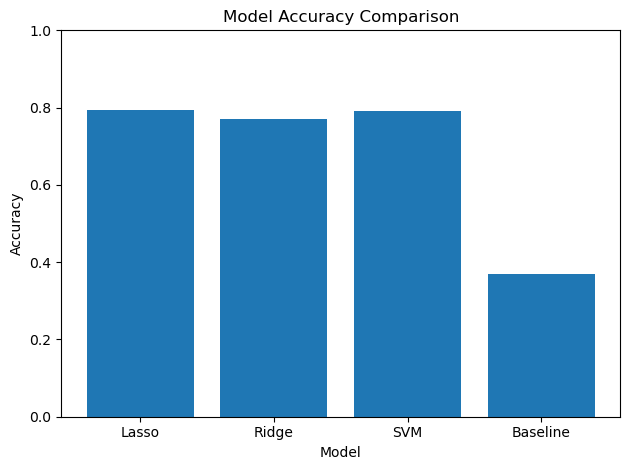

In [253]:
models = ["Lasso", "Ridge", "SVM", "Baseline"]
accuracies = [0.795, 0.77, 0.79, 0.37]

plt.figure()

plt.bar(models, accuracies)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.ylim(0, 1)  # accuracy range

plt.tight_layout()
plt.show()

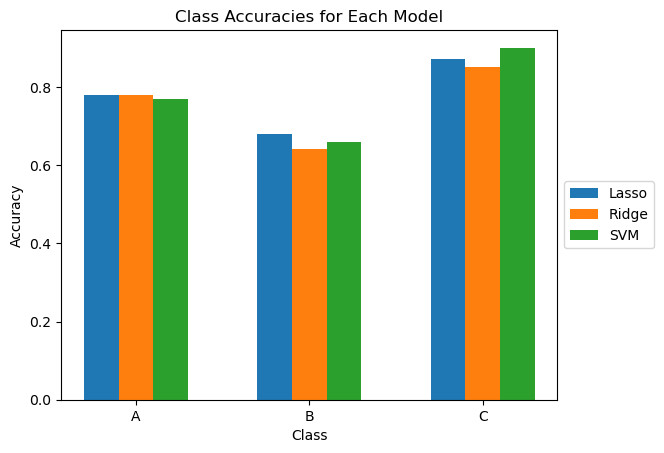

In [254]:
models = {
    "Lasso": [0.78, 0.68, 0.87],
    "Ridge": [0.78, 0.64, 0.85],
    "SVM":   [0.77, 0.66, 0.9]
}

categories = ['A', 'B', 'C']
x = np.arange(len(categories))
width = 0.2

plt.figure()

for i, (model_name, values) in enumerate(models.items()):
    plt.bar(x + i*width, values, width, label=model_name)

plt.xticks(x + width, categories)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Class Accuracies for Each Model')
plt.show()

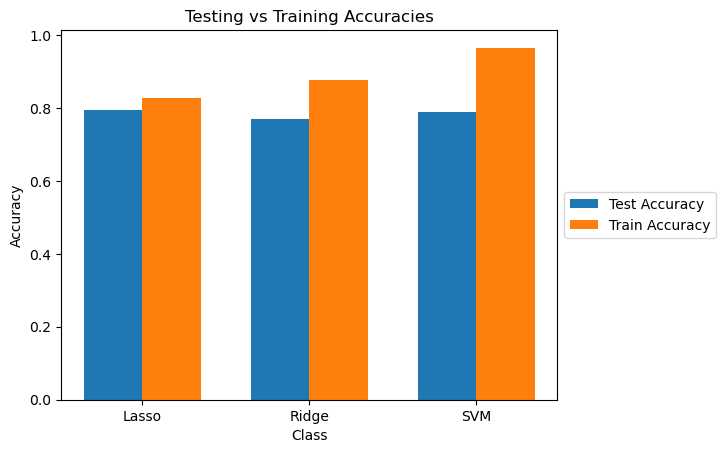

In [252]:
models = {
    "Test Accuracy": [0.795, 0.77, 0.79],
    "Train Accuracy": [0.82625, 0.87625, 0.965]
}

categories = ['Lasso', 'Ridge', 'SVM']
x = np.arange(len(categories))
width = 0.35  # slightly wider since only 2 bars

plt.figure()

n_models = len(models)

for i, (model_name, values) in enumerate(models.items()):
    plt.bar(x + (i - (n_models - 1)/2) * width, values, width, label=model_name)

plt.xticks(x, categories)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Testing vs Training Accuracies')
plt.show()